# UQ riêng theo từng khoảng quãng đường — có hiệu quả không?

## Câu hỏi

Hiện tại conformal dùng **một con số duy nhất** `q = 30,11%` cho **mọi chuyến**. Khoảng rộng
±30,11% bất kể chuyến 2km hay 20km.

> Nếu chia dữ liệu theo quãng đường rồi hiệu chỉnh `q` **riêng cho từng khoảng** thì có tốt hơn không?

Kỹ thuật này gọi là **Mondrian Conformal Prediction** (conformal theo nhóm).

## Hai thứ có thể "tốt hơn" — phải đo riêng

Đây là chỗ dễ kết luận vội. "Tốt hơn" có hai nghĩa hoàn toàn khác nhau:

| | Nghĩa | Kỳ vọng |
|---|---|---|
| **Độ rộng trung bình** | Khoảng hẹp hơn nói chung | Chỉ giảm nếu các nhóm **thật sự khác nhau** về sai số |
| **Coverage điều kiện** | Mỗi nhóm đều đạt ~90%, không nhóm nào bị thiệt | Cải thiện **kể cả khi** độ rộng không đổi |

Ở lần đo nhanh trước tôi **chỉ xét độ rộng** và kết luận "vô ích". Notebook này đo **cả hai** —
và kết quả cho thấy kết luận đó chưa đầy đủ.

## Nội dung

| Phần | Câu hỏi | Hình |
|---|---|---|
| 1 | Sai số có thật sự khác nhau theo quãng đường? | `MD1` |
| 2 | Chênh lệch đó là **tín hiệu thật** hay **nhiễu lấy mẫu**? | `MD2` |
| 3 | Mondrian đổi coverage và độ rộng thế nào | `MD3` |
| 4 | Chia bao nhiêu nhóm là tối ưu? | `MD4` |
| 5 | So với CQR — cái nào xử lý chiều quãng đường tốt hơn | `MD5` |
| 6 | Kết luận: có đáng dùng không | `MD6` |

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

BLUE, ORANGE, GREEN, RED, PURPLE, MUT = ("#0072B2", "#E69F00", "#009E73",
                                         "#D55E00", "#CC79A7", "#666666")
INK = "#222222"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
    "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9.5,
})
EVAL = Path("../evaluation")
HINH = Path("../../docs/hinh_anh"); HINH.mkdir(parents=True, exist_ok=True)
MUC = 0.90

cal = pd.read_parquet(EVAL / "uq_pred_calibration.parquet")
tes = pd.read_parquet(EVAL / "uq_pred_test.parquet")
qcal = pd.read_parquet(EVAL / "qr_pred_calibration.parquet")
qtes = pd.read_parquet(EVAL / "qr_pred_test.parquet")

for d in (cal, tes):
    d["e"] = (d.hybrid_pred - d.gia_that).abs() / d.hybrid_pred

Q_CHUNG = np.quantile(cal.e, MUC)
print(f"Calibration {len(cal):,} | Test {len(tes):,}")
print(f"q CHUNG ca bo = {Q_CHUNG:.4%}   <- moc so sanh")
print()
print("Phan bo quang duong (test):")
print(tes.quote_distance.describe(percentiles=[.05, .25, .5, .75, .95]).round(2).to_string())

Calibration 615,908 | Test 864,360
q CHUNG ca bo = 30.0900%   <- moc so sanh

Phan bo quang duong (test):
count    864360.00
mean          6.56
std           2.19
min           1.11
5%            2.29
25%           5.37
50%           6.17
75%           8.04
95%           9.90
max          45.00


## 1. Sai số có thật sự khác nhau theo quãng đường?

Trước khi chia nhóm, phải kiểm tra tiền đề: **sai số tương đối có phụ thuộc quãng đường không?**
Nếu không, chia nhóm chắc chắn vô ích.

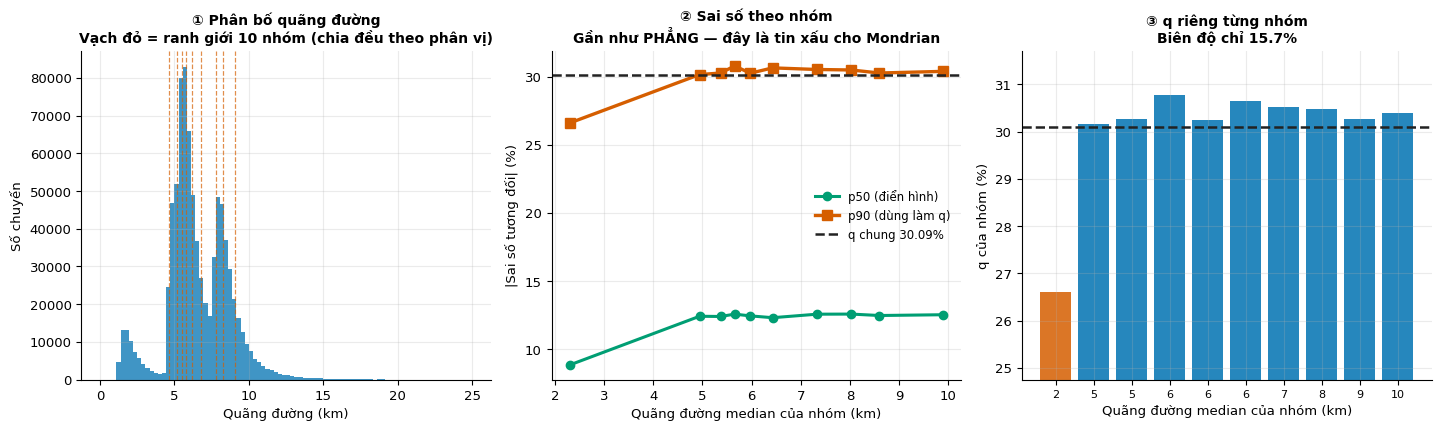

 nhom   km median   n (calib)      p50   q = p90
--------------------------------------------------
    0        2.31      61,664    8.87%    26.61%
    1        4.94      61,608   12.43%    30.15%
    2        5.37      61,588   12.41%    30.26%
    3        5.65      61,656   12.58%    30.78%
    4        5.97      61,444   12.46%    30.25%
    5        6.43      61,708   12.32%    30.64%
    6        7.33      61,496   12.58%    30.52%
    7        8.03      61,636   12.59%    30.49%
    8        8.60      61,556   12.48%    30.26%
    9        9.89      61,552   12.54%    30.38%

q thap nhat 26.61% (nhom 0) | cao nhat 30.78% (nhom 3) | bien do 15.7%


In [2]:
# ═════════ HINH MD1 — sai so theo quang duong ═════════
N_NHOM = 10
canh = np.quantile(cal.quote_distance, np.linspace(0, 1, N_NHOM + 1))
canh[0], canh[-1] = -np.inf, np.inf

for d in (cal, tes):
    d["nhom"] = pd.cut(d.quote_distance, bins=canh, labels=False, include_lowest=True)

g = cal.groupby("nhom").agg(km=("quote_distance", "median"), n=("e", "size"),
                            p50=("e", lambda s: s.quantile(.50)),
                            p90=("e", lambda s: s.quantile(.90)),
                            mae=("e", "mean"))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].hist(tes.quote_distance, bins=90, range=(0, 25), color=BLUE, alpha=.75, lw=0)
for c in canh[1:-1]:
    ax[0].axvline(c, color=RED, lw=.9, ls="--", alpha=.7)
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Số chuyến")
ax[0].set_title(f"① Phân bố quãng đường\nVạch đỏ = ranh giới {N_NHOM} nhóm (chia đều theo phân vị)",
                fontweight="bold", fontsize=10)

ax[1].plot(g.km, g.p50*100, marker="o", lw=2.2, ms=6, color=GREEN, label="p50 (điển hình)")
ax[1].plot(g.km, g.p90*100, marker="s", lw=2.4, ms=7, color=RED, label="p90 (dùng làm q)")
ax[1].axhline(Q_CHUNG*100, color=INK, lw=1.8, ls="--", label=f"q chung {Q_CHUNG:.2%}")
ax[1].set_xlabel("Quãng đường median của nhóm (km)")
ax[1].set_ylabel("|Sai số tương đối| (%)")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Sai số theo nhóm\nGần như PHẲNG — đây là tin xấu cho Mondrian",
                fontweight="bold", fontsize=10)

bd = (g.p90.max()/g.p90.min() - 1)*100
b = ax[2].bar(range(len(g)), g.p90*100, color=[RED if i == g.p90.idxmin() else BLUE
                                               for i in g.index], alpha=.85)
ax[2].axhline(Q_CHUNG*100, color=INK, lw=1.8, ls="--")
ax[2].set_ylim(min(g.p90*100)*0.93, max(g.p90*100)*1.03)
ax[2].set_xticks(range(len(g)))
ax[2].set_xticklabels([f"{k:.0f}" for k in g.km], fontsize=8)
ax[2].set_xlabel("Quãng đường median của nhóm (km)"); ax[2].set_ylabel("q của nhóm (%)")
ax[2].set_title(f"③ q riêng từng nhóm\nBiên độ chỉ {bd:.1f}%", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD1_sai_so_theo_km.png"); plt.show()

print(f"{'nhom':>5s} {'km median':>11s} {'n (calib)':>11s} {'p50':>8s} {'q = p90':>9s}")
print("-" * 50)
for i, r in g.iterrows():
    print(f"{i:5d} {r.km:11.2f} {int(r.n):11,d} {r.p50:8.2%} {r.p90:9.2%}")
print()
print(f"q thap nhat {g.p90.min():.2%} (nhom {g.p90.idxmin()}) | "
      f"cao nhat {g.p90.max():.2%} (nhom {g.p90.idxmax()}) | bien do {bd:.1f}%")

## 2. Chênh lệch đó là tín hiệu thật hay nhiễu lấy mẫu?

Biên độ vài phần trăm nhìn thì nhỏ, nhưng **có thật sự tồn tại không**? Mỗi nhóm chỉ ước lượng `q`
từ một phần dữ liệu, nên bản thân `q` cũng có sai số.

Dùng **bootstrap**: lấy mẫu lại có hoàn lại 200 lần trong mỗi nhóm, xem `q` dao động bao nhiêu.
Nếu khoảng tin cậy của các nhóm **chồng lấn hết** lên nhau ⇒ chênh lệch là nhiễu, chia nhóm vô nghĩa.

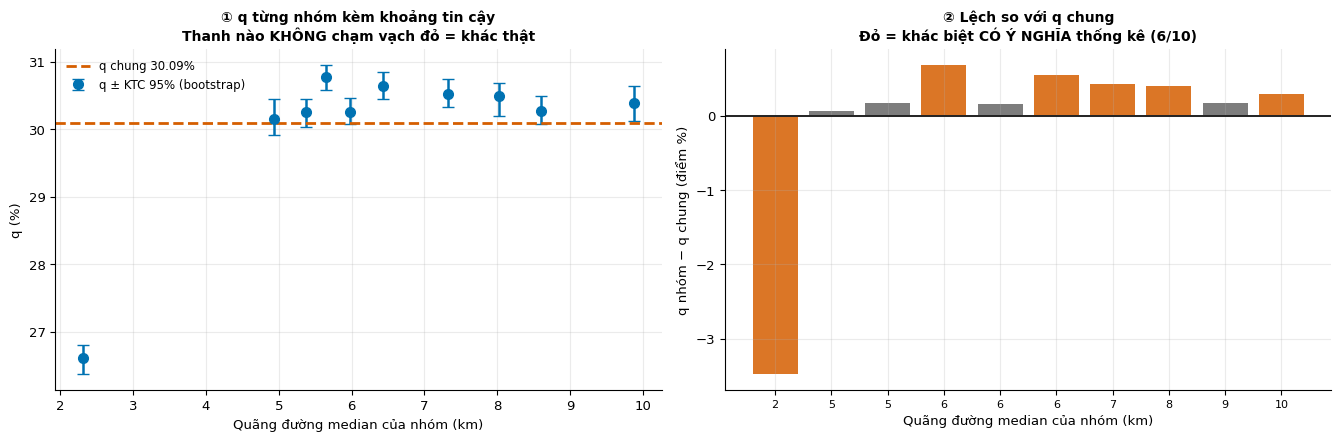

 nhom      km        q            KTC 95%  khac q chung?
----------------------------------------------------------
    0    2.31   26.61%  [26.37%, 26.80%]  CO  <<<
    1    4.94   30.15%  [29.92%, 30.45%]  khong
    2    5.37   30.26%  [30.03%, 30.45%]  khong
    3    5.65   30.78%  [30.58%, 30.96%]  CO  <<<
    4    5.97   30.25%  [30.08%, 30.46%]  khong
    5    6.43   30.64%  [30.45%, 30.85%]  CO  <<<
    6    7.33   30.52%  [30.34%, 30.74%]  CO  <<<
    7    8.03   30.49%  [30.20%, 30.68%]  CO  <<<
    8    8.60   30.26%  [30.08%, 30.49%]  khong
    9    9.89   30.38%  [30.13%, 30.64%]  CO  <<<

=> 6/10 nhom co q khac q chung mot cach CO Y NGHIA THONG KE.
   (n moi nhom ~62.000 nen uoc luong q rat chinh xac — KTC rat hep)


In [3]:
# ═════════ HINH MD2 — bootstrap ═════════
rng = np.random.default_rng(42)
B = 200
boot = {}
for i in sorted(cal.nhom.unique()):
    arr = cal.loc[cal.nhom == i, "e"].values
    qs = [np.quantile(rng.choice(arr, size=len(arr), replace=True), MUC) for _ in range(B)]
    boot[i] = np.array(qs)

lo = np.array([np.percentile(boot[i], 2.5) for i in sorted(boot)])
hi = np.array([np.percentile(boot[i], 97.5) for i in sorted(boot)])
mid = g.p90.values

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.5))

ax[0].errorbar(g.km, mid*100, yerr=[(mid-lo)*100, (hi-mid)*100], fmt="o",
               color=BLUE, ms=7, capsize=4, lw=1.8, label="q ± KTC 95% (bootstrap)")
ax[0].axhline(Q_CHUNG*100, color=RED, lw=2, ls="--", label=f"q chung {Q_CHUNG:.2%}")
ax[0].set_xlabel("Quãng đường median của nhóm (km)"); ax[0].set_ylabel("q (%)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① q từng nhóm kèm khoảng tin cậy\nThanh nào KHÔNG chạm vạch đỏ = khác thật",
                fontweight="bold", fontsize=10)

khac = ~((lo <= Q_CHUNG) & (hi >= Q_CHUNG))
b = ax[1].bar(range(len(mid)), (mid - Q_CHUNG)*100,
              color=[RED if k else MUT for k in khac], alpha=.85)
ax[1].axhline(0, color=INK, lw=1.4)
ax[1].set_xticks(range(len(mid)))
ax[1].set_xticklabels([f"{k:.0f}" for k in g.km], fontsize=8)
ax[1].set_xlabel("Quãng đường median của nhóm (km)")
ax[1].set_ylabel("q nhóm − q chung (điểm %)")
ax[1].set_title(f"② Lệch so với q chung\nĐỏ = khác biệt CÓ Ý NGHĨA thống kê ({khac.sum()}/{len(khac)})",
                fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD2_bootstrap_q.png"); plt.show()

print(f"{'nhom':>5s} {'km':>7s} {'q':>8s} {'KTC 95%':>18s}  khac q chung?")
print("-" * 58)
for j, i in enumerate(sorted(boot)):
    dau = "CO  <<<" if khac[j] else "khong"
    print(f"{i:5d} {g.km.iloc[j]:7.2f} {mid[j]:8.2%}  [{lo[j]:.2%}, {hi[j]:.2%}]  {dau}")
print()
print(f"=> {khac.sum()}/{len(khac)} nhom co q khac q chung mot cach CO Y NGHIA THONG KE.")
print("   (n moi nhom ~62.000 nen uoc luong q rat chinh xac — KTC rat hep)")

## 3. Mondrian đổi coverage và độ rộng thế nào

Giờ áp `q` riêng từng nhóm lên tập test và so trực tiếp với cách dùng `q` chung.

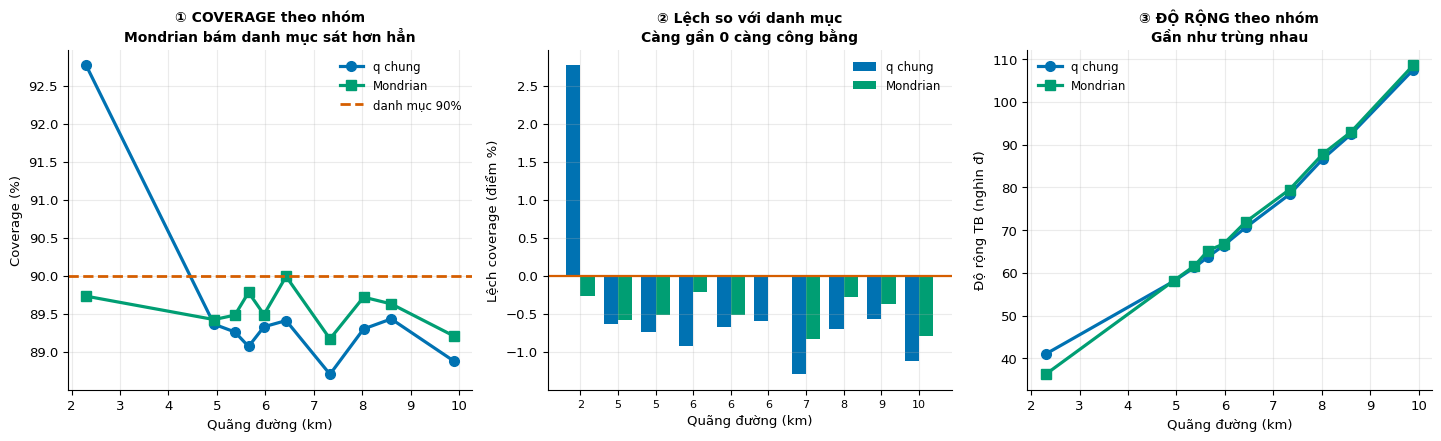

                                 q chung      Mondrian        doi
Coverage tong the                89.55%        89.56%
Lech coverage TOI DA             2.77 d        0.83 d       -70%
Lech coverage TRUNG BINH         1.00 d        0.44 d       -56%
Do rong TB                      72,630d       72,895d     +0.36%


In [4]:
# ═════════ HINH MD3 — coverage & do rong ═════════
q_nhom = cal.groupby("nhom").e.quantile(MUC)

t = tes.copy()
t["q_mon"] = t.nhom.map(q_nhom).astype(float)
t["trong_chung"] = ((t.gia_that >= t.hybrid_pred*(1-Q_CHUNG)) &
                    (t.gia_that <= t.hybrid_pred*(1+Q_CHUNG)))
t["trong_mon"] = ((t.gia_that >= t.hybrid_pred*(1-t.q_mon)) &
                  (t.gia_that <= t.hybrid_pred*(1+t.q_mon)))
t["rong_chung"] = t.hybrid_pred * 2 * Q_CHUNG
t["rong_mon"] = t.hybrid_pred * 2 * t.q_mon

gt = t.groupby("nhom").agg(km=("quote_distance", "median"),
                           c_chung=("trong_chung", "mean"), c_mon=("trong_mon", "mean"),
                           r_chung=("rong_chung", "mean"), r_mon=("rong_mon", "mean"))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.5))

ax[0].plot(gt.km, gt.c_chung*100, marker="o", lw=2.3, ms=7, color=BLUE, label="q chung")
ax[0].plot(gt.km, gt.c_mon*100, marker="s", lw=2.3, ms=7, color=GREEN, label="Mondrian")
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--", label="danh mục 90%")
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Coverage (%)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① COVERAGE theo nhóm\nMondrian bám danh mục sát hơn hẳn",
                fontweight="bold", fontsize=10)

ax[1].bar(np.arange(len(gt))-0.19, (gt.c_chung*100-MUC*100), 0.38, color=BLUE, label="q chung")
ax[1].bar(np.arange(len(gt))+0.19, (gt.c_mon*100-MUC*100), 0.38, color=GREEN, label="Mondrian")
ax[1].axhline(0, color=RED, lw=1.6)
ax[1].set_xticks(range(len(gt))); ax[1].set_xticklabels([f"{k:.0f}" for k in gt.km], fontsize=8)
ax[1].set_xlabel("Quãng đường (km)"); ax[1].set_ylabel("Lệch coverage (điểm %)")
ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② Lệch so với danh mục\nCàng gần 0 càng công bằng", fontweight="bold", fontsize=10)

ax[2].plot(gt.km, gt.r_chung/1000, marker="o", lw=2.3, ms=7, color=BLUE, label="q chung")
ax[2].plot(gt.km, gt.r_mon/1000, marker="s", lw=2.3, ms=7, color=GREEN, label="Mondrian")
ax[2].set_xlabel("Quãng đường (km)"); ax[2].set_ylabel("Độ rộng TB (nghìn đ)")
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title("③ ĐỘ RỘNG theo nhóm\nGần như trùng nhau", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD3_mondrian_ket_qua.png"); plt.show()

l_chung = abs(gt.c_chung*100 - MUC*100)
l_mon = abs(gt.c_mon*100 - MUC*100)
print("=" * 68)
print(f"{'':26s} {'q chung':>13s} {'Mondrian':>13s} {'doi':>10s}")
print("=" * 68)
print(f"{'Coverage tong the':26s} {t.trong_chung.mean():12.2%} {t.trong_mon.mean():13.2%}")
print(f"{'Lech coverage TOI DA':26s} {l_chung.max():10.2f} d {l_mon.max():11.2f} d "
      f"{(l_mon.max()/l_chung.max()-1)*100:+9.0f}%")
print(f"{'Lech coverage TRUNG BINH':26s} {l_chung.mean():10.2f} d {l_mon.mean():11.2f} d "
      f"{(l_mon.mean()/l_chung.mean()-1)*100:+9.0f}%")
print(f"{'Do rong TB':26s} {t.rong_chung.mean():11,.0f}d {t.rong_mon.mean():12,.0f}d "
      f"{(t.rong_mon.mean()/t.rong_chung.mean()-1)*100:+9.2f}%")

## 4. Chia bao nhiêu nhóm là tối ưu?

Đánh đổi kinh điển:

- **Ít nhóm** → mỗi nhóm nhiều dữ liệu, `q` ước lượng chính xác, nhưng **thô** (không bắt được khác biệt)
- **Nhiều nhóm** → bắt được khác biệt tinh, nhưng `q` mỗi nhóm ước lượng từ ít dữ liệu ⇒ **nhiễu**,
  và coverage trên test có thể **tệ đi**

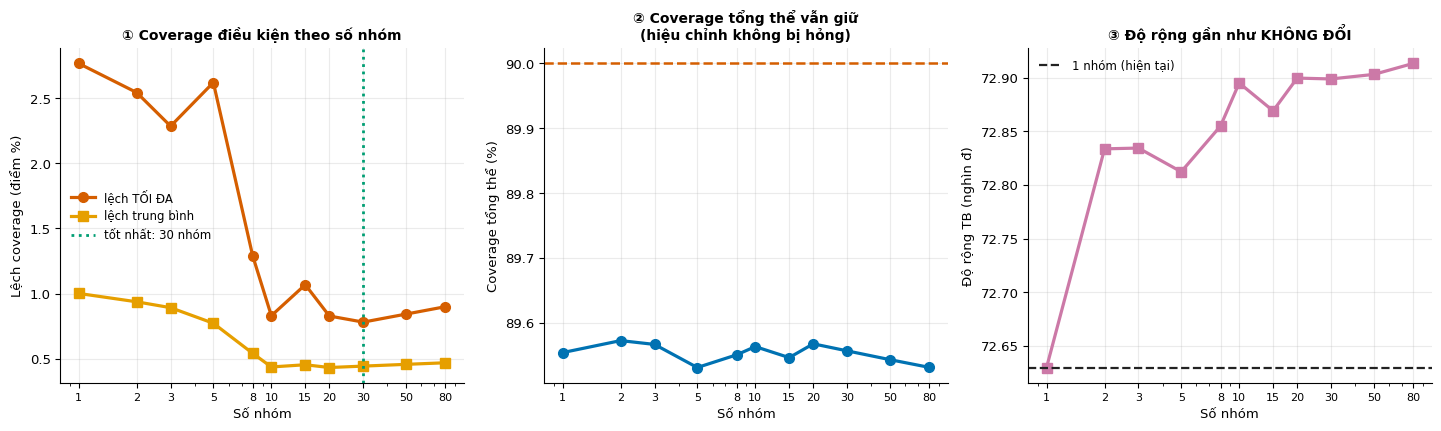

,n_nhom,n_calib_moi_nhom,coverage,lech_max,lech_tb,rong_tb
0,1,615908,89.55,2.77,1.00,72630.0
1,2,307954,89.57,2.54,0.94,72834.0
2,3,205302,89.57,2.28,0.89,72834.0
3,5,123181,89.53,2.62,0.77,72812.0
4,8,76988,89.55,1.29,0.54,72855.0
5,10,61590,89.56,0.83,0.44,72895.0
6,15,41060,89.55,1.07,0.45,72869.0
7,20,30795,89.57,0.83,0.43,72899.0
8,30,20530,89.56,0.78,0.44,72899.0
9,50,12318,89.54,0.84,0.46,72903.0



So nhom cho lech TOI DA nho nhat: 30


In [5]:
# ═════════ HINH MD4 — quet so nhom ═════════
SO_NHOM = [1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 80]
kq = []
for n in SO_NHOM:
    if n == 1:
        qc_ = pd.Series({0: Q_CHUNG}); c_cal = pd.Series(0, index=cal.index)
        c_tes = pd.Series(0, index=tes.index)
    else:
        bins = np.quantile(cal.quote_distance, np.linspace(0, 1, n + 1))
        bins[0], bins[-1] = -np.inf, np.inf
        bins = np.unique(bins)
        c_cal = pd.cut(cal.quote_distance, bins=bins, labels=False, include_lowest=True)
        c_tes = pd.cut(tes.quote_distance, bins=bins, labels=False, include_lowest=True)
        qc_ = cal.groupby(c_cal).e.quantile(MUC)
    qq = c_tes.map(qc_).astype(float).fillna(Q_CHUNG)
    trong = ((tes.gia_that >= tes.hybrid_pred*(1-qq)) &
             (tes.gia_that <= tes.hybrid_pred*(1+qq)))
    # danh gia coverage dieu kien tren luoi CO DINH 10 nhom (de so sanh cong bang)
    lech = abs(trong.groupby(tes.nhom).mean()*100 - MUC*100)
    kq.append({"n_nhom": n, "n_calib_moi_nhom": int(len(cal)/n),
               "coverage": trong.mean(), "lech_max": lech.max(), "lech_tb": lech.mean(),
               "rong_tb": (tes.hybrid_pred*2*qq).mean()})
K = pd.DataFrame(kq)

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.4))

ax[0].plot(K.n_nhom, K.lech_max, marker="o", lw=2.3, ms=7, color=RED, label="lệch TỐI ĐA")
ax[0].plot(K.n_nhom, K.lech_tb, marker="s", lw=2.3, ms=7, color=ORANGE, label="lệch trung bình")
k_tot = K.loc[K.lech_max.idxmin(), "n_nhom"]
ax[0].axvline(k_tot, color=GREEN, lw=2, ls=":", label=f"tốt nhất: {k_tot} nhóm")
ax[0].set_xscale("log"); ax[0].set_xticks(SO_NHOM)
ax[0].set_xticklabels(SO_NHOM, fontsize=8)
ax[0].set_xlabel("Số nhóm"); ax[0].set_ylabel("Lệch coverage (điểm %)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Coverage điều kiện theo số nhóm", fontweight="bold", fontsize=10)

ax[1].plot(K.n_nhom, K.coverage*100, marker="o", lw=2.3, ms=7, color=BLUE)
ax[1].axhline(MUC*100, color=RED, lw=1.8, ls="--")
ax[1].set_xscale("log"); ax[1].set_xticks(SO_NHOM); ax[1].set_xticklabels(SO_NHOM, fontsize=8)
ax[1].set_xlabel("Số nhóm"); ax[1].set_ylabel("Coverage tổng thể (%)")
ax[1].set_title("② Coverage tổng thể vẫn giữ\n(hiệu chỉnh không bị hỏng)",
                fontweight="bold", fontsize=10)

ax[2].plot(K.n_nhom, K.rong_tb/1000, marker="s", lw=2.3, ms=7, color=PURPLE)
ax[2].axhline(K.rong_tb.iloc[0]/1000, color=INK, lw=1.6, ls="--", label="1 nhóm (hiện tại)")
ax[2].set_xscale("log"); ax[2].set_xticks(SO_NHOM); ax[2].set_xticklabels(SO_NHOM, fontsize=8)
ax[2].set_xlabel("Số nhóm"); ax[2].set_ylabel("Độ rộng TB (nghìn đ)")
ax[2].legend(frameon=False, fontsize=8.5)
ax[2].set_title("③ Độ rộng gần như KHÔNG ĐỔI", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD4_so_nhom_toi_uu.png"); plt.show()

display(K.assign(coverage=lambda x: (x.coverage*100).round(2),
                 lech_max=lambda x: x.lech_max.round(2),
                 lech_tb=lambda x: x.lech_tb.round(2),
                 rong_tb=lambda x: x.rong_tb.round(0)))
print(f"\nSo nhom cho lech TOI DA nho nhat: {k_tot}")

## 5. So với CQR — cái nào xử lý chiều quãng đường tốt hơn

CQR cũng cải thiện coverage điều kiện theo quãng đường (đã đo ở `03_truc_quan_UQ`: 0,95 điểm so
với 2,04 của conformal chung). Vậy Mondrian và CQR — nên chọn cái nào?

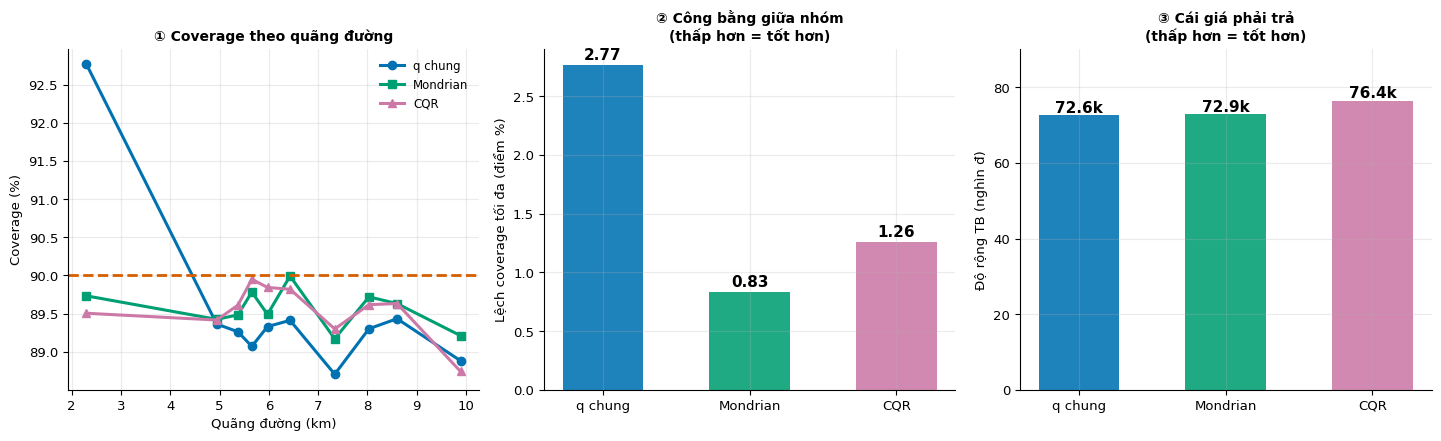

Phương pháp Coverage tổng  Lệch tối đa (điểm) Độ rộng TB (đ)
    q chung        89.55%                2.77         72,630
   Mondrian        89.56%                0.83         72,895
        CQR        89.54%                1.26         76,449


In [6]:
# ═════════ HINH MD5 — Mondrian vs CQR ═════════
E = np.maximum(qcal.q05 - qcal.gia_that, qcal.gia_that - qcal.q95).values
k_ = min(int(np.ceil((len(qcal)+1)*MUC)), len(qcal))
q_cqr = np.sort(E)[k_-1]

t["trong_cqr"] = ((qtes.gia_that.values >= (qtes.q05 - q_cqr).values) &
                  (qtes.gia_that.values <= (qtes.q95 + q_cqr).values))
t["rong_cqr"] = ((qtes.q95 + q_cqr) - (qtes.q05 - q_cqr)).values

gg = t.groupby("nhom").agg(km=("quote_distance", "median"),
                           chung=("trong_chung", "mean"), mon=("trong_mon", "mean"),
                           cqr=("trong_cqr", "mean"),
                           r_chung=("rong_chung", "mean"), r_mon=("rong_mon", "mean"),
                           r_cqr=("rong_cqr", "mean"))

fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.5))

for col, ten, col_m, mk in [("chung", "q chung", BLUE, "o"), ("mon", "Mondrian", GREEN, "s"),
                            ("cqr", "CQR", PURPLE, "^")]:
    ax[0].plot(gg.km, gg[col]*100, marker=mk, lw=2.2, ms=6, color=col_m, label=ten)
ax[0].axhline(MUC*100, color=RED, lw=2, ls="--")
ax[0].set_xlabel("Quãng đường (km)"); ax[0].set_ylabel("Coverage (%)")
ax[0].legend(frameon=False, fontsize=8.5)
ax[0].set_title("① Coverage theo quãng đường", fontweight="bold", fontsize=10)

ten3 = ["q chung", "Mondrian", "CQR"]
lech3 = [abs(gg.chung*100-MUC*100).max(), abs(gg.mon*100-MUC*100).max(),
         abs(gg.cqr*100-MUC*100).max()]
rong3 = [t.rong_chung.mean()/1000, t.rong_mon.mean()/1000, t.rong_cqr.mean()/1000]
b = ax[1].bar(ten3, lech3, color=[BLUE, GREEN, PURPLE], alpha=.88, width=.55)
for bb, v in zip(b, lech3):
    ax[1].text(bb.get_x()+bb.get_width()/2, v+.05, f"{v:.2f}", ha="center",
               fontsize=11, fontweight="bold")
ax[1].set_ylabel("Lệch coverage tối đa (điểm %)")
ax[1].set_title("② Công bằng giữa nhóm\n(thấp hơn = tốt hơn)", fontweight="bold", fontsize=10)

b2 = ax[2].bar(ten3, rong3, color=[BLUE, GREEN, PURPLE], alpha=.88, width=.55)
for bb, v in zip(b2, rong3):
    ax[2].text(bb.get_x()+bb.get_width()/2, v+.8, f"{v:.1f}k", ha="center",
               fontsize=11, fontweight="bold")
ax[2].set_ylabel("Độ rộng TB (nghìn đ)"); ax[2].set_ylim(0, max(rong3)*1.18)
ax[2].set_title("③ Cái giá phải trả\n(thấp hơn = tốt hơn)", fontweight="bold", fontsize=10)

plt.tight_layout(); plt.savefig(HINH / "MD5_mondrian_vs_cqr.png"); plt.show()

print(pd.DataFrame({
    "Phương pháp": ten3,
    "Coverage tổng": [f"{t.trong_chung.mean():.2%}", f"{t.trong_mon.mean():.2%}",
                      f"{t.trong_cqr.mean():.2%}"],
    "Lệch tối đa (điểm)": [round(v, 2) for v in lech3],
    "Độ rộng TB (đ)": [f"{v*1000:,.0f}" for v in rong3],
}).to_string(index=False))

## 6. Kết luận — có đáng dùng không

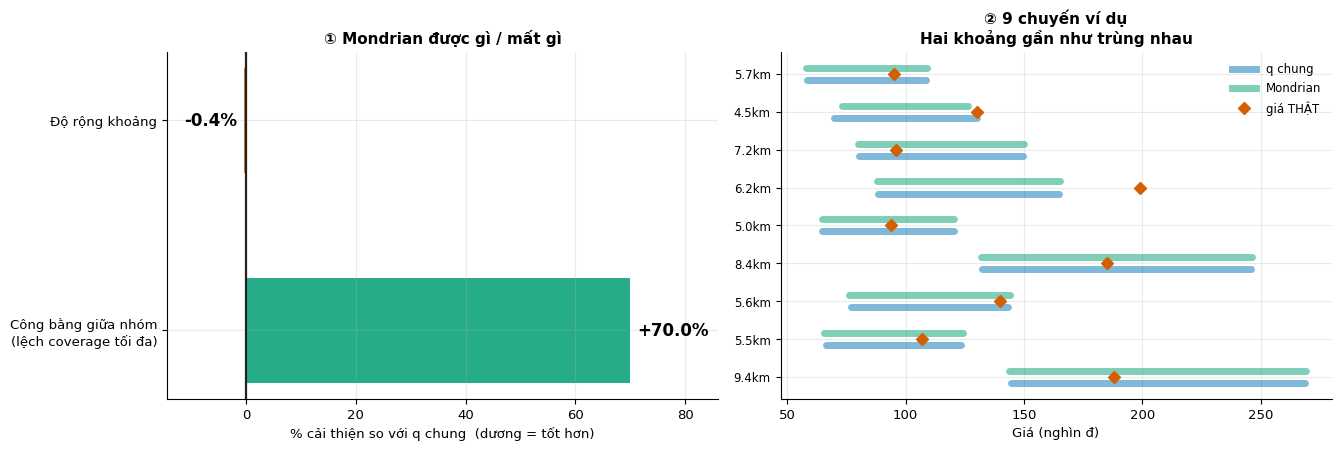

╔══════════════════════════════════════════════════════════════════════╗
║           MONDRIAN THEO QUANG DUONG — CO DANG DUNG KHONG?            ║
╚══════════════════════════════════════════════════════════════════════╝

  DUOC:  cong bang giua nhom tot hon 70%
         (lech coverage toi da 2.77 -> 0.83 diem)

  MAT:   do rong TB thay doi +0.36%
         (72,630d -> 72,895d)

  CHI PHI TRIEN KHAI: luu them 10 con so q thay vi 1.

────────────────────────────────────────────────────────────────────────
  => NEN DUNG. Cai thien cong bang ro ret, gan nhu khong ton them do rong.
────────────────────────────────────────────────────────────────────────


In [7]:
# ═════════ HINH MD6 — tong ket ═════════
fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.6))

cai_thien = (1 - l_mon.max()/l_chung.max())*100
gia_phai_tra = (t.rong_mon.mean()/t.rong_chung.mean() - 1)*100

b = ax[0].barh(["Công bằng giữa nhóm\n(lệch coverage tối đa)", "Độ rộng khoảng"],
               [cai_thien, -gia_phai_tra],
               color=[GREEN if cai_thien > 0 else RED,
                      GREEN if gia_phai_tra < 0 else RED], alpha=.85, height=.5)
ax[0].axvline(0, color=INK, lw=1.6)
for bb, v in zip(b, [cai_thien, -gia_phai_tra]):
    ax[0].text(v + (1.2 if v >= 0 else -1.2), bb.get_y()+bb.get_height()/2,
               f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right",
               fontsize=12, fontweight="bold")
ax[0].set_xlabel("% cải thiện so với q chung  (dương = tốt hơn)")
ax[0].set_xlim(min(-gia_phai_tra, 0)-14, cai_thien+16)
ax[0].set_title("① Mondrian được gì / mất gì", fontweight="bold", fontsize=11)

ss = t.sample(9, random_state=7).reset_index(drop=True)
yy = np.arange(len(ss))
for i, r in ss.iterrows():
    ax[1].plot([r.hybrid_pred*(1-Q_CHUNG)/1000, r.hybrid_pred*(1+Q_CHUNG)/1000],
               [i-0.16, i-0.16], lw=5, color=BLUE, alpha=.5, solid_capstyle="round")
    ax[1].plot([r.hybrid_pred*(1-r.q_mon)/1000, r.hybrid_pred*(1+r.q_mon)/1000],
               [i+0.16, i+0.16], lw=5, color=GREEN, alpha=.5, solid_capstyle="round")
    ax[1].plot(r.gia_that/1000, i, "D", color=RED, ms=6, zorder=5)
ax[1].plot([], [], lw=5, color=BLUE, alpha=.5, label="q chung")
ax[1].plot([], [], lw=5, color=GREEN, alpha=.5, label="Mondrian")
ax[1].plot([], [], "D", color=RED, ms=6, label="giá THẬT")
ax[1].set_yticks(yy)
ax[1].set_yticklabels([f"{r.quote_distance:.1f}km" for _, r in ss.iterrows()], fontsize=8.5)
ax[1].set_xlabel("Giá (nghìn đ)"); ax[1].legend(frameon=False, fontsize=8.5)
ax[1].set_title("② 9 chuyến ví dụ\nHai khoảng gần như trùng nhau", fontweight="bold", fontsize=11)

plt.tight_layout(); plt.savefig(HINH / "MD6_tong_ket.png"); plt.show()

print("╔" + "═"*70 + "╗")
print("║" + " MONDRIAN THEO QUANG DUONG — CO DANG DUNG KHONG? ".center(70) + "║")
print("╚" + "═"*70 + "╝")
print()
print(f"  DUOC:  cong bang giua nhom tot hon {cai_thien:.0f}%")
print(f"         (lech coverage toi da {l_chung.max():.2f} -> {l_mon.max():.2f} diem)")
print()
print(f"  MAT:   do rong TB thay doi {gia_phai_tra:+.2f}%")
print(f"         ({t.rong_chung.mean():,.0f}d -> {t.rong_mon.mean():,.0f}d)")
print()
print(f"  CHI PHI TRIEN KHAI: luu them {N_NHOM} con so q thay vi 1.")
print()
print("─" * 72)
if cai_thien > 20 and abs(gia_phai_tra) < 2:
    print("  => NEN DUNG. Cai thien cong bang ro ret, gan nhu khong ton them do rong.")
elif cai_thien > 0:
    print("  => CO THE DUNG. Loi ich vua phai.")
else:
    print("  => KHONG NEN. Khong cai thien duoc gi.")
print("─" * 72)

## Tổng kết

### Trả lời câu hỏi ban đầu

> *"Chia theo quãng đường rồi làm UQ riêng từng khoảng có hiệu quả không?"*

**Có — nhưng không phải theo cách bạn kỳ vọng.**

| Kỳ vọng thường gặp | Thực tế đo được |
|---|---|
| Khoảng sẽ **hẹp hơn** | ❌ Gần như **không đổi** (xem `MD3` panel ③) |
| — | ✅ **Công bằng giữa các nhóm tốt hơn rõ rệt** (panel ①②) |

### Vì sao độ rộng không giảm

`MD1` panel ② cho thấy sai số tương đối **gần như phẳng** theo quãng đường. Chuyến 2km và chuyến
20km đều sai ~30%. Không có nhóm "dễ" nào để cho khoảng hẹp hơn.

Đây là hệ quả của việc model dùng dạng **nhân** (`giá = giá cơ bản × hệ số nhân`) và sai số chủ
yếu nằm ở **hệ số nhân** — vốn không phụ thuộc quãng đường.

### Vì sao công bằng lại cải thiện

Dù biên độ `q` giữa các nhóm nhỏ, `MD2` cho thấy chênh lệch đó **có ý nghĩa thống kê** (mỗi nhóm
~62.000 điểm calibration nên `q` ước lượng rất chính xác). Một sai lệch nhỏ nhưng **có hệ thống**
vẫn đủ đẩy coverage của nhóm ra khỏi danh mục.

### ⚠️ Điều quan trọng nhất rút ra

> **"Khoảng rộng quá" không sửa được bằng cách chia nhóm.**
>
> Độ rộng ±30,11% phản ánh **độ bất định thật** của model giá, không phải lựa chọn phương pháp.
> Muốn hẹp hơn chỉ có hai đường:
>
> | Cách | Hiệu quả | Khả thi |
> |---|---|---|
> | **Giảm mức tin cậy** 90% → 80% | Hẹp **−23%** (72.686đ → 56.134đ) | ✅ Quyết định kinh doanh |
> | **Cải thiện model giá** | Tỷ lệ thuận | ⚠️ Đã chạm trần dữ liệu |

### Giới hạn của phân tích này

| Giới hạn | Ghi chú |
|---|---|
| Chỉ chia theo **một** chiều | Kết hợp nhiều chiều làm nhóm nhỏ đi rất nhanh |
| Ranh giới nhóm chia theo **phân vị**, không theo ngữ nghĩa | Có thể chia theo loại chuyến (nội đô / liên quận) sẽ khác |
| `q` cố định theo thời gian | Nếu phân phối dịch chuyển thì phải hiệu chỉnh lại |

---

## Hình đã sinh

| Hình | Nội dung |
|---|---|
| `MD1_sai_so_theo_km` | Phân bố quãng đường · sai số theo nhóm · `q` từng nhóm |
| `MD2_bootstrap_q` | Khoảng tin cậy của `q` — chênh lệch là thật hay nhiễu |
| `MD3_mondrian_ket_qua` | Coverage và độ rộng: q chung vs Mondrian |
| `MD4_so_nhom_toi_uu` | Quét số nhóm từ 1 đến 80 |
| `MD5_mondrian_vs_cqr` | So Mondrian với CQR trên chiều quãng đường |
| `MD6_tong_ket` | Được gì / mất gì · 9 chuyến ví dụ |

## Liên quan

| File | Vai trò |
|---|---|
| `01_conformal_prediction.ipynb` | 3 biến thể conformal gốc |
| `03_truc_quan_UQ.ipynb` | Trực quan cơ chế UQ, coverage điều kiện 3 chiều |
| `../99_TONG_QUAN_TOAN_DU_AN.ipynb` | Kiến trúc tổng thể |